In [144]:
import pickle
import os 
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import numpy as np
from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import cdist
import seaborn as sns

In [145]:
plt.rcParams['figure.figsize']=(8,8) #rescale figures
sc.settings.verbosity = 3
sc.logging.print_versions()
import os
import sys
sc.set_figure_params(scanpy=True, dpi_save=400,dpi=150)
import matplotlib

/tmp/ipykernel_1798451/2915364982.py:3: FutureWarning: Use `print_header` instead
  sc.logging.print_versions()


In [146]:
figdir = '../fig2_supp8e_kernelneighwithswaps/'

In [147]:

dataset = 'Moffitt2018'
dataset_full = 'dataset1_merfish_moffitt2018'
pickle_path = '../../datasets/' + dataset_full + '/results/simulations/pickles/'
N_curr = 50
nneigh = 10
nswaps_nbd = 2
par_bw = 0.01
suffix = '_normnolog_nov2024_1k'
aligntool = 'moscot'
mode = 'multislice'
gtalign = False
transcrnbd = 'variabletranscr'
# adata_spa_path = pickle_path + 'multi_slice_simulated_' + 'sptsz_' + str(N_curr)  + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nswaps_nbd) + suffix + '.pickle' # '_old.pickle'        


# # read spatial file 
# if not os.path.exists(adata_spa_path):
#     sys.exit() 
# with open(adata_spa_path, 'rb') as handle:
#     adata_spa = pickle.load(handle)


kernels = {} 
for nswaps_nbd in [2, 5, 10, 20, 50]:
    kernel_path = figdir +  dataset + '/kernel_wt_sptsz_' + str(N_curr) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nswaps_nbd) + '_parbw_' + str(par_bw) + suffix + '_' +  aligntool + '_' +  mode + '_' + transcrnbd + '_gtalign_' + str(gtalign) + '_sim.pickle'
    with open(kernel_path, 'rb') as handle:
        kernels[nswaps_nbd] = pickle.load(handle)

/tmp/ipykernel_1798451/2045047368.py:27: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  kernels[nswaps_nbd] = pickle.load(handle)


In [148]:
from collections import Counter

kernel_df = pd.DataFrame()

for nbd_sz in kernels.keys():
    kernel_all = []
    for entry in kernels[nbd_sz].keys():
        for entry1 in range(11):
            for entry2 in [entry1-1, entry1+1]:
                if (entry2 < 0) or (entry2 > 10):
                    continue 
             
                kernel_tmp = kernels[nbd_sz][entry][str(entry2) + '_' + str(entry1)].copy()
                kernel_tmp = (kernel_tmp > 0).sum(axis=0).tolist()
                kernel_all.extend(kernel_tmp)

    my_counter = Counter(kernel_all)
    df = pd.DataFrame.from_dict(my_counter, orient='index', columns=['Moffitt2018-Swap' + str(nbd_sz)])
    kernel_df = pd.concat([kernel_df, df], axis=1).fillna(0)            
    

kernel_df.sort_index(inplace=True)
# print(kernel_df)
import anndata
kernel_ann = anndata.AnnData(X=kernel_df.T)

kernel_ann.obs['Dataset-Swap'] = kernel_ann.obs_names.astype(str)
# sc.pp.log1p(kernel_ann)
# sc.pl.matrixplot(kernel_ann, groupby='Dataset-Swap', var_names=kernel_ann.var_names, cmap='viridis', categories_order=list(kernel_ann.obs.index))



/project/mlobo6/miniconda3/envs/cell2location/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


## Choi

In [150]:

dataset = 'Choi2023'
dataset_full = 'dataset2_merfish_retina_2022'
pickle_path = '../../datasets/' + dataset_full + '/results/simulations/pickles/'
N_curr = 50
nneigh = 10
nswaps_nbd = 2
par_bw = 0.01
suffix = '_norm1knolog'
aligntool = 'moscot'
mode = 'multislice'
gtalign = False
transcrnbd = 'variabletranscr'
# adata_spa_path = pickle_path + 'multi_slice_simulated_' + 'sptsz_' + str(N_curr)  + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nswaps_nbd) + suffix + '.pickle' # '_old.pickle'        


# # read spatial file 
# if not os.path.exists(adata_spa_path):
#     sys.exit() 
# with open(adata_spa_path, 'rb') as handle:
#     adata_spa = pickle.load(handle)


kernels = {} 
for nswaps_nbd in [2, 5, 10, 20, 50]:
    kernel_path = figdir +  dataset + '/kernel_wt_sptsz_' + str(N_curr) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nswaps_nbd) + '_parbw_' + str(par_bw) + suffix + '_' +  aligntool + '_' +  mode + '_' + transcrnbd + '_gtalign_' + str(gtalign) + '_sim.pickle'
    with open(kernel_path, 'rb') as handle:
        kernels[nswaps_nbd] = pickle.load(handle)

/tmp/ipykernel_1798451/76354626.py:27: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  kernels[nswaps_nbd] = pickle.load(handle)


In [152]:
kernel_df = pd.DataFrame()

for nbd_sz in kernels.keys():
    kernel_all = []
    for entry in kernels[nbd_sz].keys():
        for entry1 in range(11):
            for entry2 in [entry1-1, entry1+1]:
                if (entry2 < 0) or (entry2 > 10):
                    continue 
             
                kernel_tmp = kernels[nbd_sz][entry][str(entry2) + '_' + str(entry1)].copy()
                kernel_tmp = (kernel_tmp > 0).sum(axis=0).tolist()
                kernel_all.extend(kernel_tmp)
    my_counter = Counter(kernel_all)
    df = pd.DataFrame.from_dict(my_counter, orient='index', columns=['Choi-Swap' + str(nbd_sz)])
    # print(df)
    kernel_df = pd.concat([kernel_df, df], axis=1).fillna(0)            
    

kernel_df.sort_index(inplace=True)
# print(kernel_df)
# import anndata
kernel_tmp = anndata.AnnData(X=kernel_df.T)

kernel_tmp.obs['Dataset-Swap'] = kernel_tmp.obs_names.astype(str)
# sc.pp.log1p(kernel_ann)
# sc.pl.matrixplot(kernel_ann, groupby='Dataset-Swap', var_names=kernel_ann.var_names, cmap='viridis', categories_order=list(kernel_ann.obs.index))



kernel_ann = anndata.concat([ kernel_ann, kernel_tmp], join='outer',fill_value=0.0)
    

/project/mlobo6/miniconda3/envs/cell2location/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


## Haviv2025

In [154]:

dataset = 'Haviv2025'
dataset_full = 'dataset9_xenuim'
pickle_path = '../../datasets/' + dataset_full + '/results/simulations/pickles/'
N_curr = 50
nneigh = 10
nswaps_nbd = 2
par_bw = 0.01
suffix = '_norm1knolog'
aligntool = 'moscot'
mode = 'multislice'
gtalign = False
transcrnbd = 'variabletranscr'
# adata_spa_path = pickle_path + 'multi_slice_simulated_' + 'sptsz_' + str(N_curr)  + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nswaps_nbd) + suffix + '.pickle' # '_old.pickle'        


# # read spatial file 
# if not os.path.exists(adata_spa_path):
#     sys.exit() 
# with open(adata_spa_path, 'rb') as handle:
#     adata_spa = pickle.load(handle)


kernels = {} 
for nswaps_nbd in [2, 5, 10, 20, 50]:
    kernel_path = figdir +  dataset + '/kernel_wt_sptsz_' + str(N_curr) + '_nneigh_' + str(nneigh) + '_nbdswaps_' + str(nswaps_nbd) + '_parbw_' + str(par_bw) + suffix + '_' +  aligntool + '_' +  mode + '_' + transcrnbd + '_gtalign_' + str(gtalign) + '_sim.pickle'
    with open(kernel_path, 'rb') as handle:
        kernels[nswaps_nbd] = pickle.load(handle)

/tmp/ipykernel_1798451/2692365582.py:27: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  kernels[nswaps_nbd] = pickle.load(handle)


In [160]:
kernel_df = pd.DataFrame()

for nbd_sz in kernels.keys():
    kernel_all = []
    for entry in kernels[nbd_sz].keys():
        for entry1 in range(11):
            for entry2 in [entry1-1, entry1+1]:
                if (entry2 < 0) or (entry2 > 10):
                    continue 
             
                kernel_tmp = kernels[nbd_sz][entry][str(entry2) + '_' + str(entry1)].copy()
                kernel_tmp = (kernel_tmp > 0).sum(axis=0).tolist()
                kernel_all.extend(kernel_tmp)
            
    my_counter = Counter(kernel_all)
    df = pd.DataFrame.from_dict(my_counter, orient='index', columns=['Haviv-Swap' + str(nbd_sz)])
    kernel_df = pd.concat([kernel_df, df], axis=1).fillna(0)            
    

kernel_df.sort_index(inplace=True)
# print(kernel_df)
# import anndata
kernel_tmp = anndata.AnnData(X=kernel_df.T)

kernel_tmp.obs['Dataset-Swap'] = kernel_tmp.obs_names.astype(str)
# sc.pp.log1p(kernel_ann)
# sc.pl.matrixplot(kernel_ann, groupby='Dataset-Swap', var_names=kernel_ann.var_names, cmap='viridis', categories_order=list(kernel_ann.obs.index))



kernel_ann = anndata.concat([ kernel_ann, kernel_tmp], join='outer', fill_value=0.0)
    

/project/mlobo6/miniconda3/envs/cell2location/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


## plot matrixplot

In [163]:
sc.pp.log1p(kernel_ann)



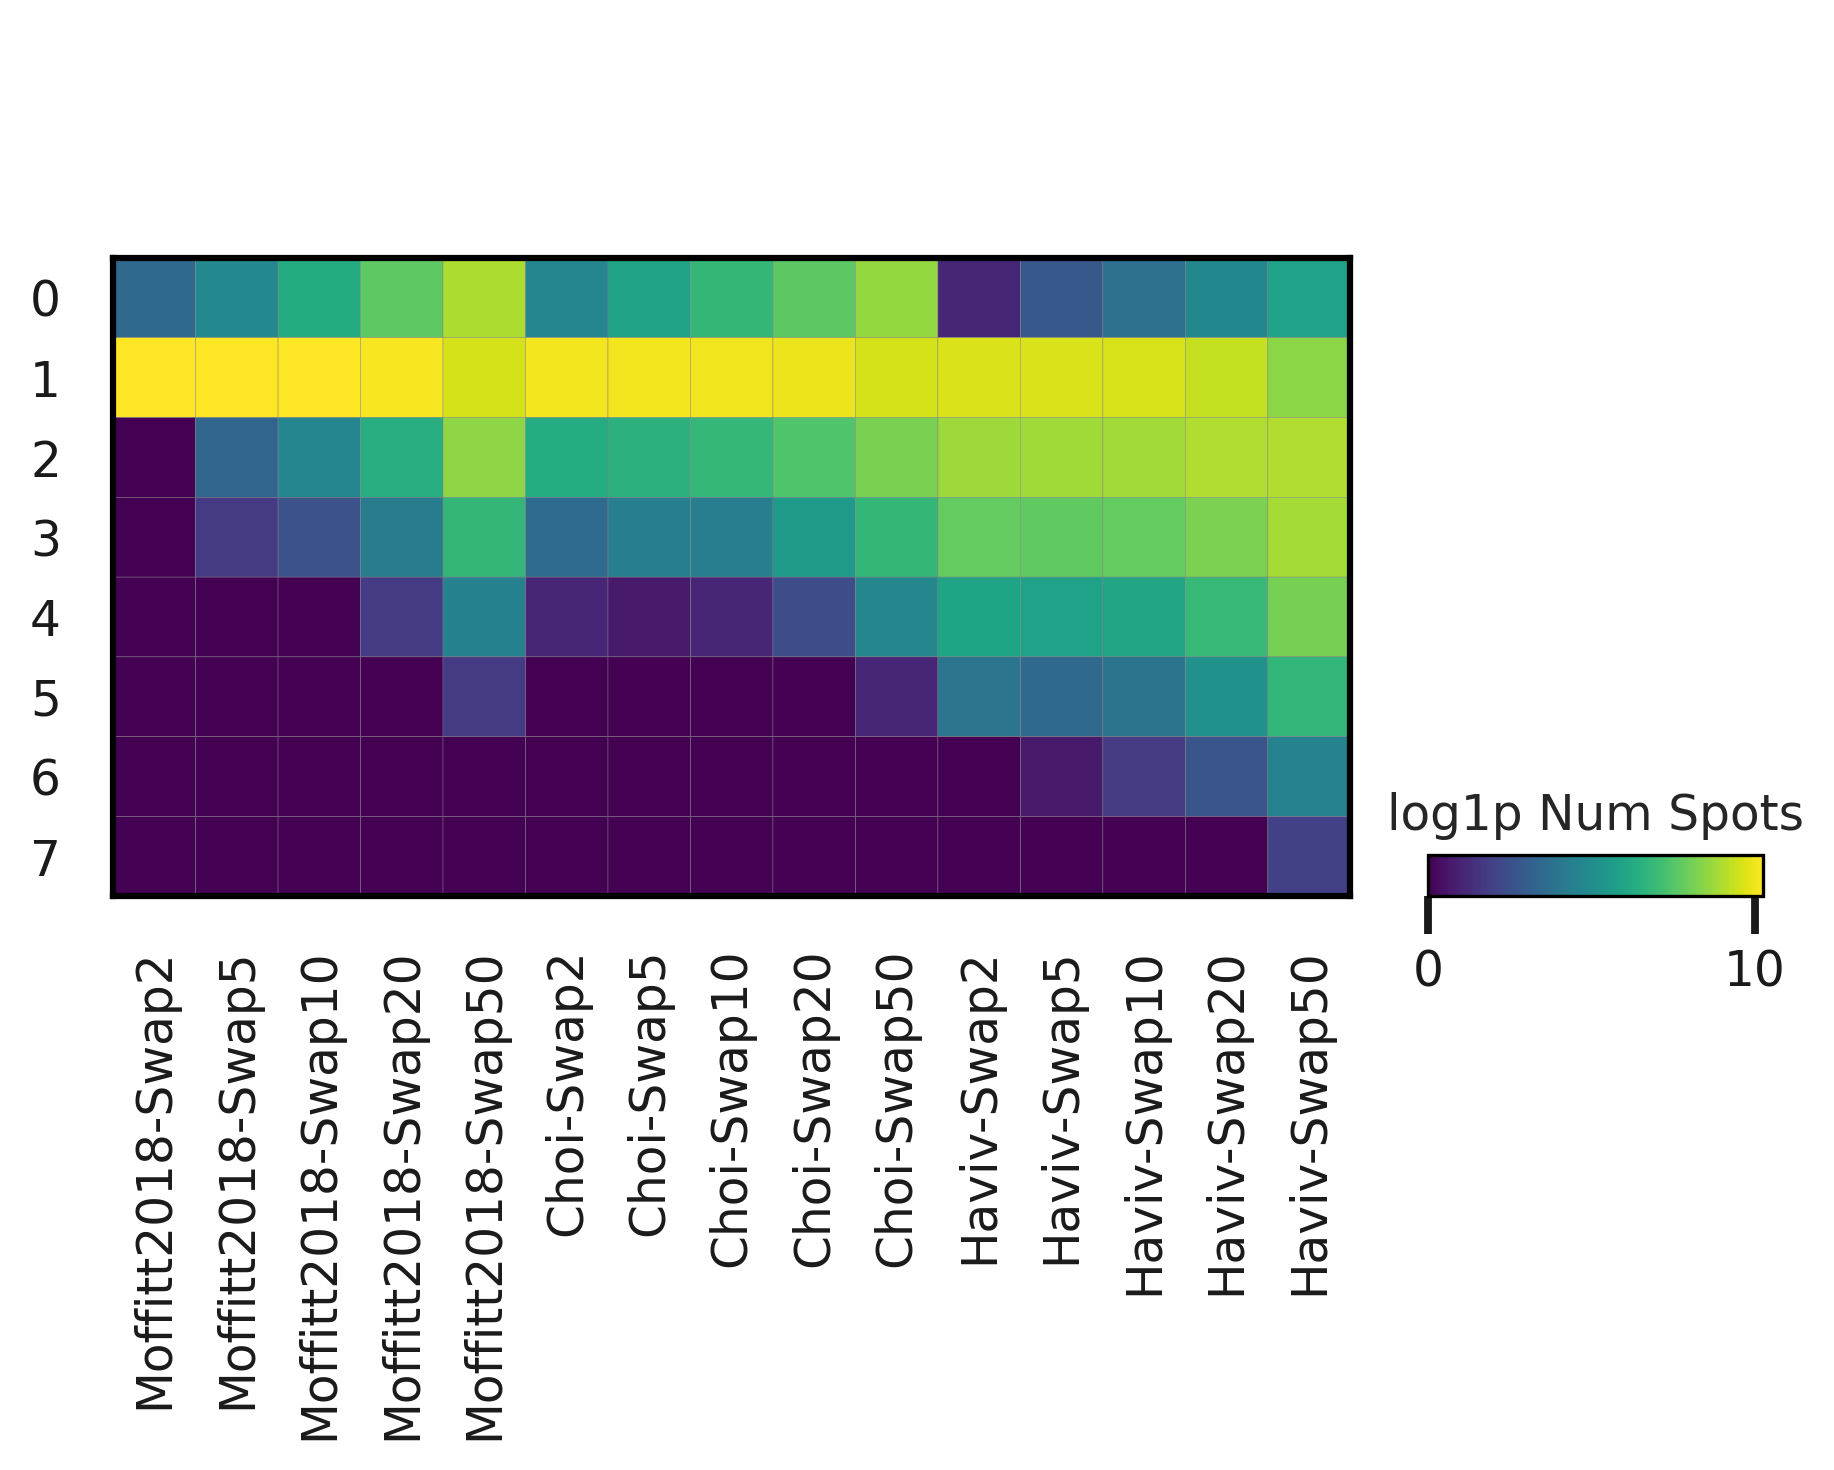

In [168]:
sc.pl.matrixplot(kernel_ann, groupby='Dataset-Swap', swap_axes=True,  var_names=kernel_ann.var_names, cmap='viridis', categories_order=list(kernel_ann.obs.index), colorbar_title='log1p Num Spots',save='_matrixplot.pdf')
